In [2]:
pip install pandas numpy matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats 
import statsmodels.api as sm 
import statsmodels.formula.api as smf 
from statsmodels.stats.weightstats import ztest 
from statsmodels.stats.anova import anova_lm 
sns.set(style="whitegrid")

In [14]:
df = pd.read_csv("QLBH.csv",encoding = "cp1258") # thay file bạn muốn 
print("Kích thước dữ liệu:", df.shape) 
df.head()

Kích thước dữ liệu: (2823, 28)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,05/07/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,07/01/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie


In [17]:
# Convert kiểu dữ liệu 
numeric_cols = ["QUANTITYORDERED", "PRICEEACH", "SALES"] # ví dụ 
datetime_cols = ["ORDERDATE"] # ví dụ 
category_cols = ["COUNTRY", "TERRITORY","CONTACTLASTNAME"]

In [18]:
for col in numeric_cols: 
    df[col] = pd.to_numeric(df[col], errors="coerce") 
for col in datetime_cols: 
    df[col] = pd.to_datetime(df[col], errors="coerce") 
for col in category_cols: 
    df[col] = df[col].astype("category")

In [ ]:
# Đổi tên cột 
df = df.rename(columns={"QUANTITYORDERED":"Quantity", "PRICEEACH":"UnitPrice", "SALES":"Revenue"})

,ORDERNUMBER,Quantity,UnitPrice,ORDERLINENUMBER,Revenue,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie


In [21]:
# Xử lý missing value 
df = df.fillna({"Quantity":df["Quantity"].median(), "UnitPrice":df["UnitPrice"].mean()})

In [23]:
# Xử lý outlier bằng IQR 
Q1 = df["Quantity"].quantile(0.25) 
Q3 = df["Quantity"].quantile(0.75) 
IQR = Q3 - Q1 
df = df[(df["Quantity"] >= Q1 - 1.5*IQR) & (df["Quantity"] <= Q3 + 1.5*IQR)]

In [25]:
print("\n--- Thống kê cơ bản ---") 
print(df.describe(include="all"))


--- Thống kê cơ bản ---
         ORDERNUMBER     Quantity    UnitPrice  ORDERLINENUMBER       Revenue  \
count    2815.000000  2815.000000  2815.000000      2815.000000   2815.000000   
unique           NaN          NaN          NaN              NaN           NaN   
top              NaN          NaN          NaN              NaN           NaN   
freq             NaN          NaN          NaN              NaN           NaN   
mean    10258.303375    34.969805    83.623282         6.465719   3537.552554   
min     10100.000000     6.000000    26.880000         1.000000    482.130000   
25%     10179.000000    27.000000    68.745000         3.000000   2202.050000   
50%     10262.000000    35.000000    95.700000         6.000000   3181.530000   
75%     10333.000000    43.000000   100.000000         9.000000   4485.040000   
max     10425.000000    66.000000   100.000000        18.000000  12536.500000   
std        91.874739     9.467267    20.190816         4.228984   1814.654314   

  

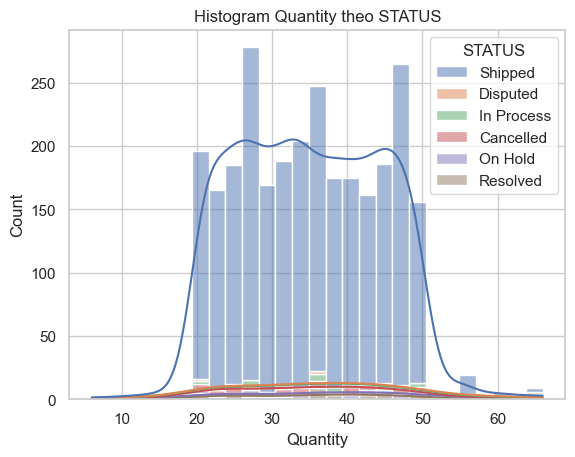

In [41]:
# Numeric 
# Histogram số lượng, phân biệt theo sản phẩm
sns.histplot(data=df, x="Quantity", hue="STATUS", kde=True, multiple="stack")
plt.title("Histogram Quantity theo STATUS")
plt.show()


In [42]:
data = df["Quantity"].dropna() 
print("\nShapiro-Wilk:", stats.shapiro(data))


Shapiro-Wilk: ShapiroResult(statistic=0.9722123742103577, pvalue=5.726720595322555e-23)


In [43]:
print("Kolmogorov-Smirnov:", stats.kstest((data - data.mean())/data.std(ddof=1), 'norm'))

Kolmogorov-Smirnov: KstestResult(statistic=0.07039517746504775, pvalue=1.4179491779045393e-12, statistic_location=-0.8418273497212606, statistic_sign=1)


In [44]:
t_stat, p_val = stats.ttest_1samp(data, 50) 
print("\nOne-sample t-test: t=%.3f, p=%.3f" % (t_stat, p_val)) 
if p_val < 0.05: print("❌ Bác bỏ H0: Trung bình khác 50") 
else: print("✅ Không bác bỏ H0: Trung bình ≈ 50")


One-sample t-test: t=-84.232, p=0.000
❌ Bác bỏ H0: Trung bình khác 50


In [45]:
z_stat, p_val = ztest(df["Revenue"], value=1000) 
print("\nZ-test: z=%.3f, p=%.3f" % (z_stat, p_val))


Z-test: z=74.193, p=0.000


In [47]:
groupA = df[df["STATUS"]=="A"]["Quantity"] 
groupB = df[df["STATUS"]=="B"]["Quantity"] 
t_stat, p_val = stats.ttest_ind(groupA, groupB, nan_policy="omit") 
print("\nIndependent t-test: t=%.3f, p=%.3f" % (t_stat, p_val))


Independent t-test: t=nan, p=nan


In [49]:
# ANOVA: Revenue giữa nhiều nhóm sản phẩm 
model = smf.ols('Revenue ~ C(STATUS)', data=df).fit() 
anova_table = sm.stats.anova_lm(model, typ=2) 
print("\nANOVA:\n", anova_table)


ANOVA:
                  sum_sq      df        F    PR(>F)
C(STATUS)  4.726612e+07     5.0  2.88032  0.013409
Residual   9.219152e+09  2809.0      NaN       NaN
